Ejercicio 1

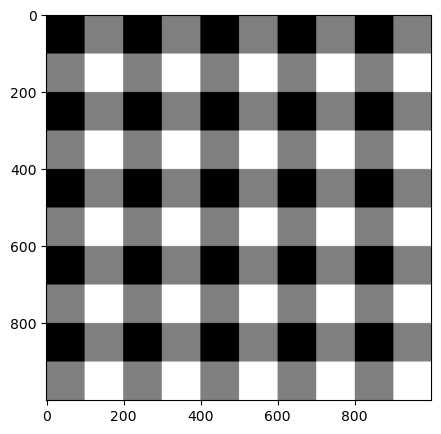

In [20]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

plt.rcParams['figure.figsize']=[10,5]

tamanio_img = 1000
R = np.ones((tamanio_img, tamanio_img)) * 255
G = np.ones((tamanio_img, tamanio_img)) * 255
B = np.ones((tamanio_img, tamanio_img)) * 255

imagen=np.dstack((R,G,B))
imagen=np.array(imagen,dtype=int)

for i in range(100, 1000, 200):
    for j in range(0, 1000, 200):
        for k in range(100):
            for l in range(100):
                imagen[k+i,l+j] = [127, 127, 127]

for i in range(0, 1000, 200):
    for j in range(100, 1000, 200):
        for k in range(100):
            for l in range(100):
                imagen[k+i,l+j] = [127, 127, 127]

for i in range(0, 1000, 200):
    for j in range(0, 1000, 200):
        for k in range(100):
            for l in range(100):
                imagen[k+i,l+j] = [0, 0, 0]

plt.figure()
plt.imshow(imagen)
plt.show()

Ejercicio 2

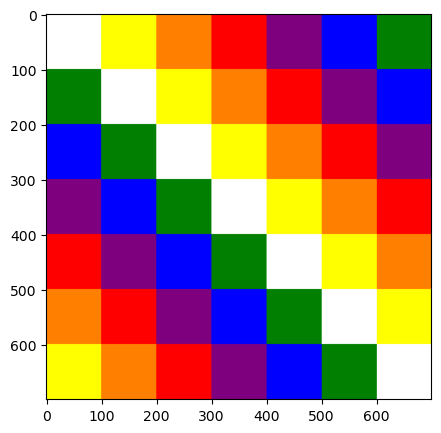

In [69]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

plt.rcParams['figure.figsize']=[10,5]

tamanio_img = 700
R = np.ones((tamanio_img, tamanio_img)) * 255
G = np.ones((tamanio_img, tamanio_img)) * 255
B = np.ones((tamanio_img, tamanio_img)) * 255

imagen=np.dstack((R,G,B))
imagen=np.array(imagen,dtype=int)

for i in range(0, 600, 100):
    for k in range(100):
        for l in range(100):
            imagen[k+i, l+i+100] = [255, 255, 0]
for i in range(0, 600, 100):
    for k in range(100):
        for l in range(100):
            imagen[k+i+100, l+i] = [0, 127, 0]

for i in range(0, 500, 100):
    for k in range(100):
        for l in range(100):
            imagen[k+i, l+i+200] = [255, 127, 0]
for i in range(0, 500, 100):
    for k in range(100):
        for l in range(100):
            imagen[k+i+200, l+i] = [0, 0, 255]

for i in range(0, 400, 100):
    for k in range(100):
        for l in range(100):
            imagen[k+i, l+i+300] = [255, 0, 0]
for i in range(0, 400, 100):
    for k in range(100):
        for l in range(100):
            imagen[k+i+300, l+i] = [127, 0, 127]

for i in range(0, 300, 100):
    for k in range(100):
        for l in range(100):
            imagen[k+i, l+i+400] = [127, 0, 127]
for i in range(0, 300, 100):
    for k in range(100):
        for l in range(100):
            imagen[k+i+400, l+i] = [255, 0, 0]

for i in range(0, 200, 100):
    for k in range(100):
        for l in range(100):
            imagen[k+i, l+i+500] = [0, 0, 255]
for i in range(0, 200, 100):
    for k in range(100):
        for l in range(100):
            imagen[k+i+500, l+i] = [255, 127, 0]

for k in range(100):
    for l in range(100):
        imagen[k, l+600] = [0, 127, 0]
for k in range(100):
    for l in range(100):
        imagen[k+600, l] = [255, 255, 0]

plt.figure()
plt.imshow(imagen)
plt.show()

Ejercicio 3

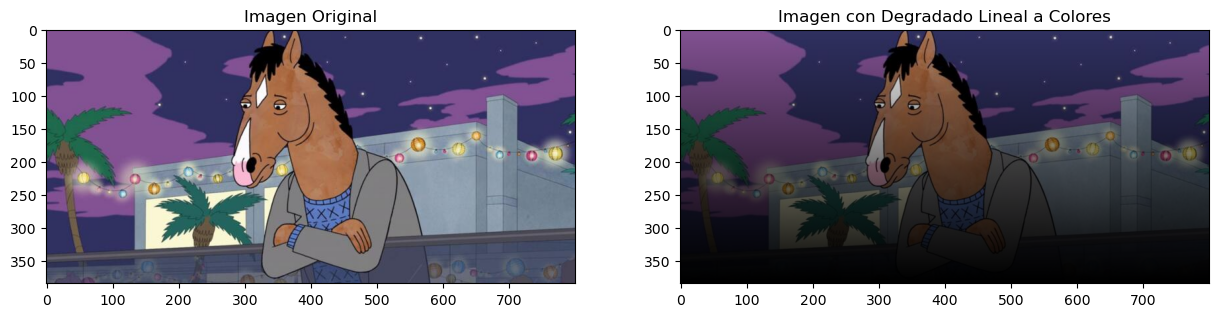

In [77]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('ImagenExamen.jpeg', cv2.IMREAD_COLOR_RGB)

rows, _, _ = imagen.shape
degradado = np.linspace(1, 0, rows).reshape(-1, 1, 1)
imagen_degradado = (imagen * degradado).astype(np.uint8)

plt.figure(figsize=(15, 10))
plt.subplot(121)
plt.imshow(imagen)
plt.title('Imagen Original')

plt.subplot(122)
plt.imshow(imagen_degradado)
plt.title('Imagen con Degradado Lineal a Colores')
plt.show()

Ejercicio 4

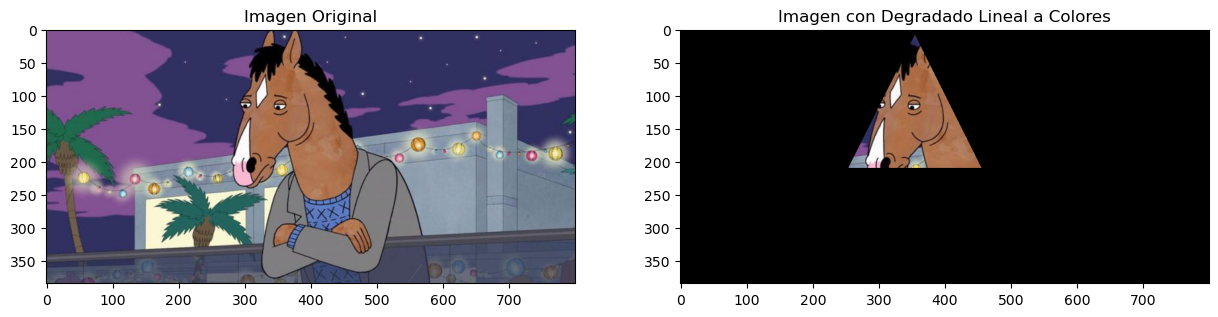

In [135]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def crearMascara(shape, center, size):
    mask = np.zeros(shape[:2], dtype=np.uint8)
    points = [
        (center[0], center[1] - size),
        (center[0] - size, center[1] + size),
        (center[0] + size, center[1] + size)
    ]
    cv2.fillPoly(mask, [np.array(points, dtype=np.int32)], 255)
    return mask

imagen = cv2.imread('ImagenExamen.jpeg')
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

h, w, _ = imagen.shape
mask = crearMascara((h, w), center=(w // 2.25, h // 3.5), size=100)

img_triangulo = cv2.bitwise_and(imagen, imagen, mask=mask)

plt.figure(figsize=(15, 10))
plt.subplot(121)
plt.imshow(imagen)
plt.title('Imagen Original')

plt.subplot(122)
plt.imshow(img_triangulo)
plt.title('Imagen con Degradado Lineal a Colores')
plt.show()


Ejercicio 5

Punto de interes al azar

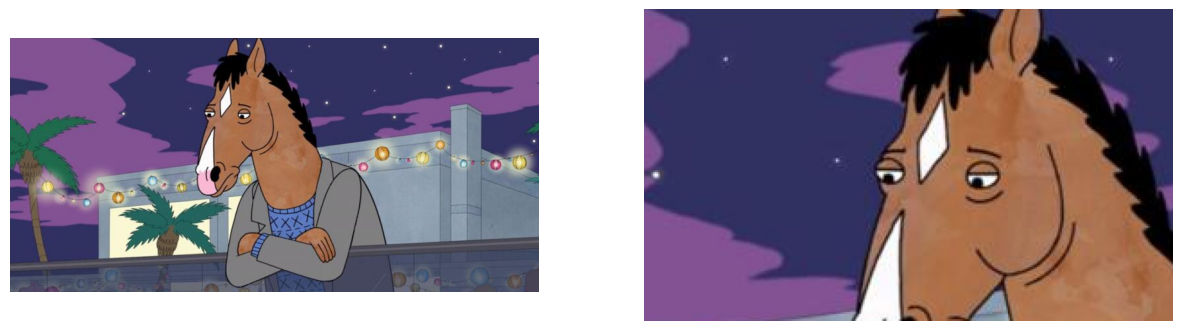

In [160]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random as r

imagen = cv2.imread('ImagenExamen.jpeg', cv2.IMREAD_COLOR_RGB)
y1 = r.randint(0, 192)
y2 = r.randint(193, 384)
x1 = r.randint(0, 400)
x2 = r.randint(401, 800)

recorte = imagen[y1:y2, x1:x2]

cv2.imwrite('imgExamRecorte.jpg', cv2.cvtColor(recorte, cv2.COLOR_RGB2BGR))
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(imagen)
plt.axis('off')

plt.subplot(122)
plt.imshow(recorte)
plt.axis('off')
plt.show()

Histogramas

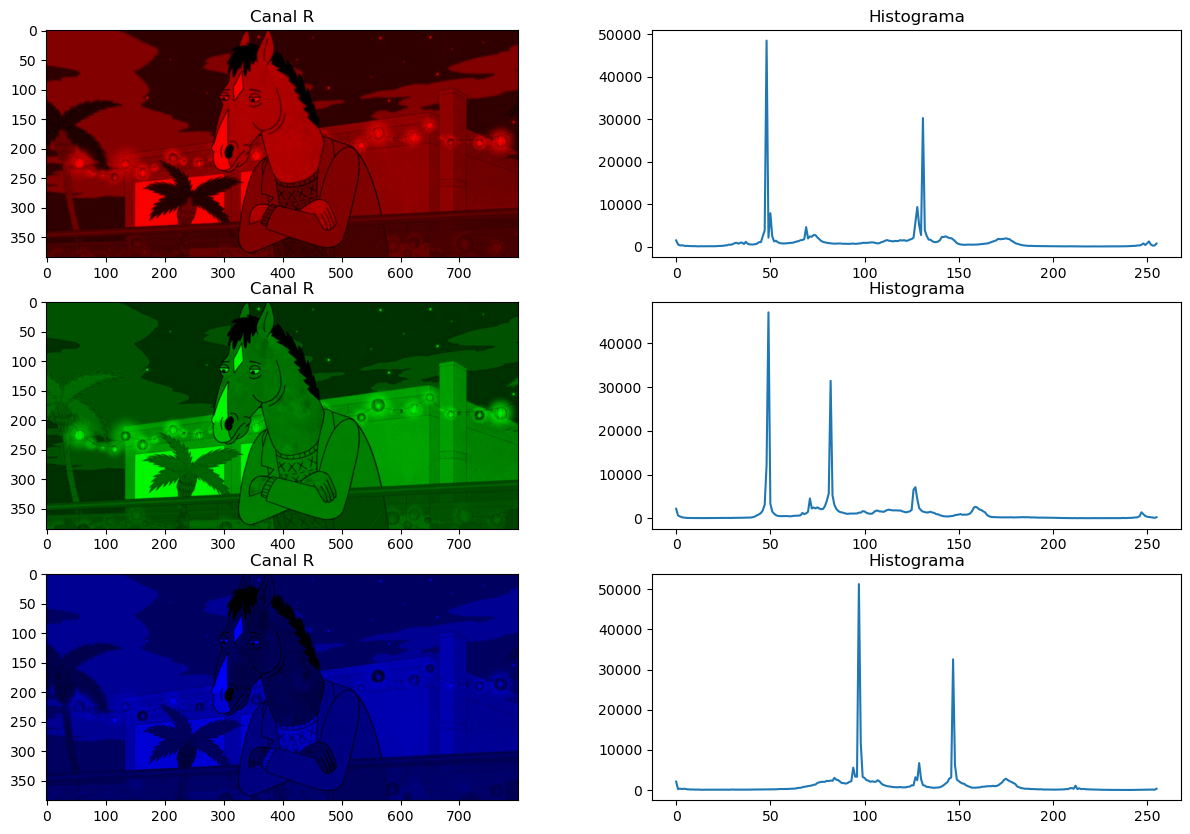

In [84]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('ImagenExamen.jpeg', cv2.IMREAD_COLOR)
imagen = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

r = img[:, :, 2]
g = img[:, :, 1]
b = img[:, :, 0]

r_img = np.zeros_like(imagen)
r_img[:, :, 0] = r

g_img = np.zeros_like(imagen)
g_img[:, :, 1] = g

b_img = np.zeros_like(imagen)
b_img[:, :, 2] = b

histr = cv2.calcHist([r_img], [0], None, [256], [0, 256])
histg = cv2.calcHist([g_img], [1], None, [256], [0, 256])
histb = cv2.calcHist([b_img], [2], None, [256], [0, 256])

plt.figure(figsize=(15,10))
plt.subplot(321)
plt.imshow(r_img)
plt.title('Canal R')

plt.subplot(322)
plt.plot(histr)
plt.title('Histograma')

plt.subplot(323)
plt.imshow(g_img)
plt.title('Canal R')

plt.subplot(324)
plt.plot(histg)
plt.title('Histograma')

plt.subplot(325)
plt.imshow(b_img)
plt.title('Canal R')

plt.subplot(326)
plt.plot(histb)
plt.title('Histograma')
plt.show()

Solarizacion, Posterizacion y Umbralizacion

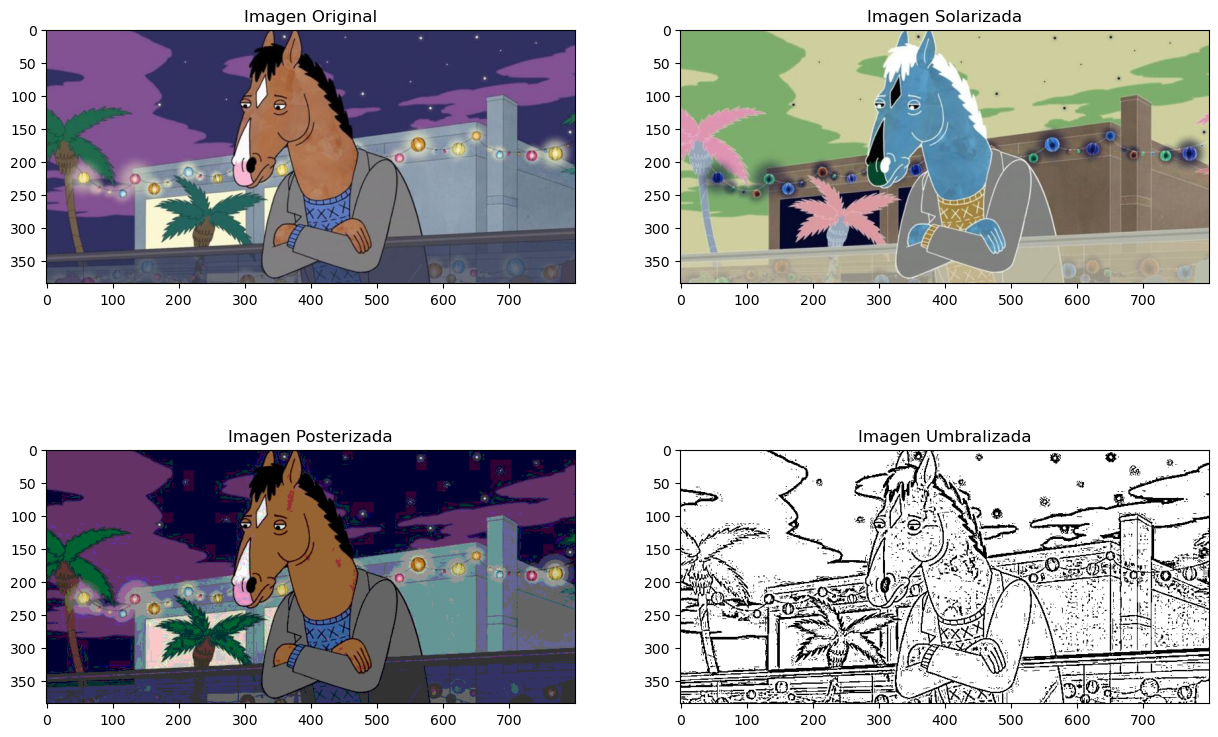

In [124]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('ImagenExamen.jpeg', cv2.IMREAD_COLOR_RGB)
grises = cv2.imread('ImagenExamen.jpeg', 0)

def solarizar(imagen, umbral):
    img_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return img_sol

def posterizar(imagen, factor):
    img_pos = (imagen // factor) * factor
    return img_pos

img_sol = solarizar(imagen, 0)
img_pos = posterizar(imagen, 50)
umbral_adap = cv2.adaptiveThreshold(grises, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

cv2.imwrite('ImgExamSol.jpeg', cv2.cvtColor(img_sol, cv2.COLOR_RGB2BGR))
cv2.imwrite('ImgExamPos.jpeg', cv2.cvtColor(img_pos, cv2.COLOR_RGB2BGR))
cv2.imwrite('ImgExamUmbral.jpeg', umbral_adap)

plt.figure(figsize=(15,10))
plt.subplot(221)
plt.imshow(imagen)
plt.title('Imagen Original')

plt.subplot(222)
plt.imshow(img_sol)
plt.title('Imagen Solarizada')

plt.subplot(223)
plt.imshow(img_pos)
plt.title('Imagen Posterizada')

plt.subplot(224)
plt.imshow(umbral_adap, cmap='gray')
plt.title('Imagen Umbralizada')
plt.show()

Filtro

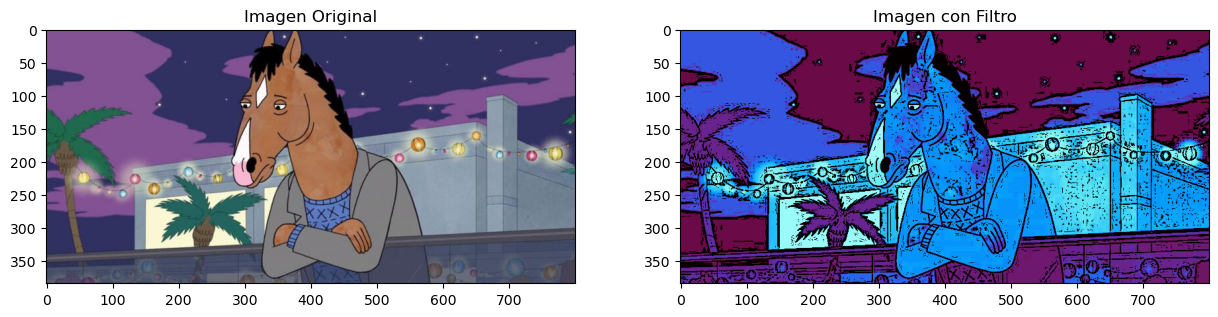

In [123]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('ImagenExamen.jpeg', cv2.IMREAD_COLOR_RGB)
grises = cv2.imread('ImagenExamen.jpeg', 0)

umbral_adap = cv2.adaptiveThreshold(grises, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

ecualizada = cv2.equalizeHist(grises)

imagen_ycrcb = cv2.cvtColor(imagen, cv2.COLOR_BGR2YCrCb)
imagen_ycrcb[:, :, 0] = cv2.equalizeHist(imagen_ycrcb[:, :, 0])
ecuColor = cv2.cvtColor(imagen_ycrcb, cv2.COLOR_YCrCb2BGR)
ecu = cv2.cvtColor(ecuColor, cv2.COLOR_BGR2RGB)

img = cv2.bitwise_and(ecu, ecu, mask=umbral_adap)

color = cv2.applyColorMap(img, cv2.COLORMAP_INFERNO)

cv2.imwrite('ImgExamFiltro.jpeg', cv2.cvtColor(color, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(15,10))
plt.subplot(121)
plt.imshow(imagen)
plt.title('Imagen Original')

plt.subplot(122)
plt.imshow(color)
plt.title('Imagen con Filtro')
plt.show()

Teoria

A que nos referimos si hablamos de una imagen digital?

Una matriz de pixeles

Que es la profundidad del color?

Es la cantidad de bits usados para representar el color de cada pixel

Cual es la diferencia entre CMKY y RGB?

RGB es un modelo aditivo, mientras que CMYK es un modelo sustractivo